# OWNML MACHINE LEARNING CANVAS
**Designed for:** Ray Santos | **Designed by:** Amanda Silveira | **Date:** 19/04/2026 | **Iteration:** 1.0

## VALUE PROPOSITION
Reduzir churn e proteger a Receita Recorrente Mensal (Monthly Recurring Revenue - MRR) por meio de um modelo preditivo que identifica antecipadamente clientes com alto risco de cancelamento, permitindo ações proativas das equipes de relacionamento com clientes, marketing e liderança...

## PREDICTION TASK
Classificação Binária. 
**Input:** Um perfil de cliente (dados financeiros, contratuais e comportamentais).
**Output:** Probabilidade [0 a 1] de Churn nos próximos 30 dias.

> Veja a documentação completa no arquivo `docs/ML_Canvas.md`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

Deu bom


## 1.1 Volume: Carregamento do Dataset


In [3]:
# Lendo os dados brutos
data_path = '../data/raw/Telco-Customer-Churn.csv'

# Verificamos se o arquivo existe antes de carregar
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Volume do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas/features.")
    display(df.head())
else:
    print("Dataset não encontrado. Faça o download e coloque em data/raw/")


Volume do dataset: 7043 linhas e 21 colunas/features.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1.2 Qualidade: Tipos e Dados Faltantes
Vamos investigar a integridade dos tipos e valores nulos.


In [5]:
# Informação geral para verificação dos Tipos (Dtypes)
df.info()

print("\nNulos Aparentes:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Pegadinha Identificada na Qualidade:** A feature `TotalCharges` consta como formato *object* (`string`) mas representa moedas. Isso ocorre porque clientes com `tenure` (tempo em meses) de 0 não tem total cobrado ainda e o sistema exportou como um espaço e branco `" "`. Vamos varrer esses logs e substituí-los.


In [6]:
# Tratando os dados faltantes ocultos em Total Charges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Nulos reais após conversão: {df['TotalCharges'].isnull().sum()}")

# Substituindo nulos por zero no TotalCharges e descartando ID 
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop('customerID', axis=1)
print("Dados higienizados.")


Nulos reais após conversão: 11
Dados higienizados.


## 1.3 Distribuição e Classes
Como estão os recursos que estamos alimentando para a rede neural?


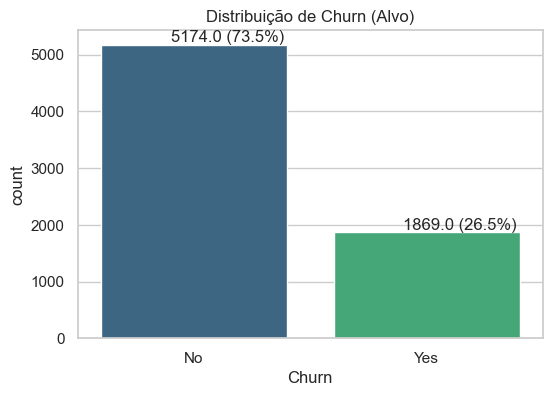

In [7]:
# Distância de Desbalanceamento do Target 'Churn'
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribuição de Churn (Alvo)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({(p.get_height()/len(df))*100:.1f}%)', 
                (p.get_x() + 0.3, p.get_height() + 50))
plt.show()


Observamos claramente a classe minoritária (Classe de interesse). Por isso usaremos PR-AUC!

Agora vamos conferir os numéricos:


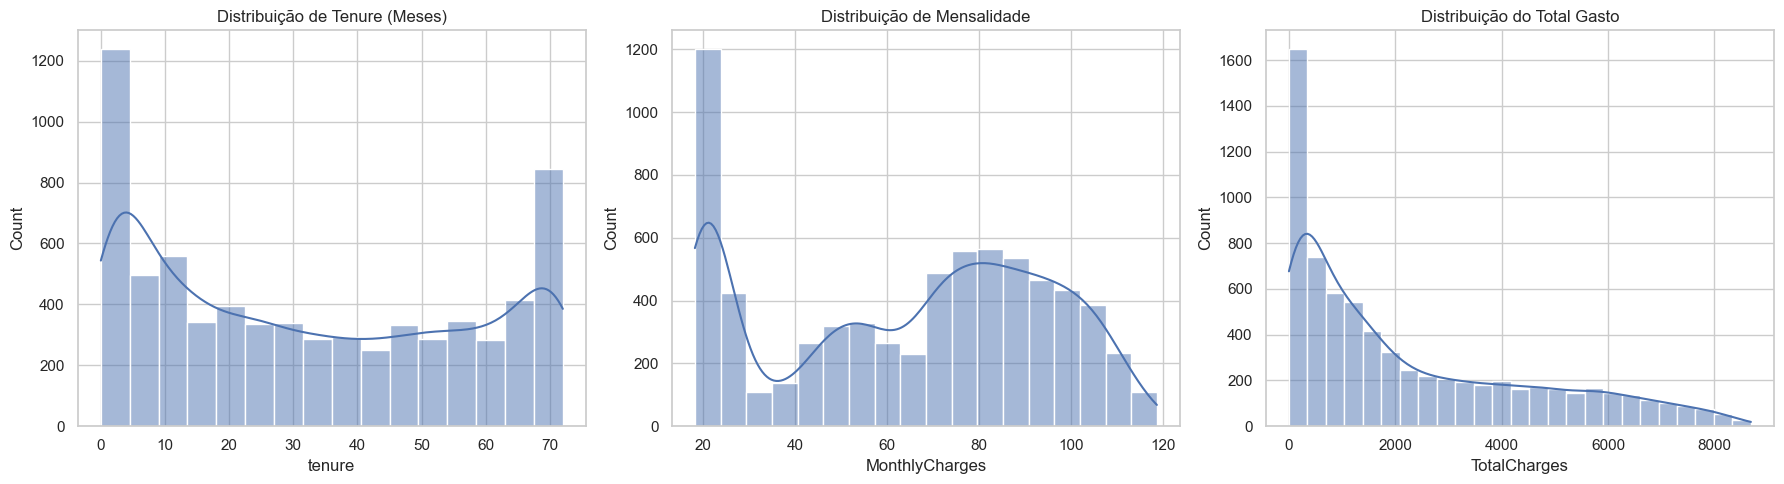

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['tenure'], kde=True, ax=axes[0]).set_title('Distribuição de Tenure (Meses)')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1]).set_title('Distribuição de Mensalidade')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2]).set_title('Distribuição do Total Gasto')
plt.tight_layout()
plt.show()


## 1.4 Data Readiness (Prontidão para ML)
Com base nesta EDA, para enviar ao Pipeline no Scikit-Learn ou Rede Neural PyTorch, as transformações necessárias são:
1. **Target Encoding**: Transformar `Churn` de string (Yes/No) para int (1/0).
2. **One-Hot Encoding**: Converter atributos categóricos sem ondem como `PaymentMethod`. 
3. **Escalonamento**: `Tenure` e `MonthlyCharges` receberão um *StandardScaler* na pipeline para minimizar a perda no Gradiente Descendente do Pytorch.
